# HydroSense-Kenya: Scientific Computing for Smart Irrigation
## Milestone 3: Core Numerical Methods Engine
---
### 1. Introduction

In this milestone, we manually implement core numerical methods to analyze agricultural thresholds and rates of change. We avoid black-box solvers to ensure absolute control over computational tolerances.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

# Add the src directory to the system path to import our custom engine
sys.path.append(os.path.abspath("../src"))

# THIS IS THE CRITICAL LINE:
from numerical_methods import (bisection_method, newton_raphson_method, secant_method, 
                               central_difference, trapezoidal_rule, simpsons_rule, gaussian_elimination)

# Load datasets
base_path = "../data/raw"
weather_df = pd.read_csv(os.path.join(base_path, "weather_daily.csv"), na_values=['NA', '']).ffill()
soil_df = pd.read_csv(os.path.join(base_path, "soil_sensor_data.csv"), na_values=['NA', ''])
soil_df['soil_moisture_pct'] = soil_df.groupby('zone_id')['soil_moisture_pct'].transform(lambda x: x.interpolate())

### 2. Applied Root Finding: Critical Temperature ThresholdsScientific Context: 
Suppose the farm's irrigation pumps can only compensate for a maximum Evapotranspiration (ET) rate of 6.0 mm/day. Given fixed wind speed ($2.5 m/s$), solar index ($0.7$), and humidity ($65%$), at what specific temperature $T$ does the $ET$ reach this critical $6.0 mm/day$ limit? We define the root-finding function:$$f(T) = (0.12T + 0.35(2.5) + 2.4(0.7) - 0.025(65)) - 6.0 = 0$$The derivative for the Newton-Raphson method is simply $f'(T) = 0.12$.

In [14]:
# Fixed environmental parameters
W, S, H = 2.5, 0.7, 65.0
critical_et = 6.0

# Define the function f(T) and its derivative f'(T)
def et_target_func(T):
    return (0.12 * T) + (0.35 * W) + (2.4 * S) - (0.025 * H) - critical_et

def et_deriv_func(T):
    return 0.12 

# Execute Root Finding Algorithms and UNPACK the 4 returned variables
root_bisect, iters_b, err_b, status_b = bisection_method(et_target_func, a=10, b=50)
root_newton, iters_n, err_n, status_n = newton_raphson_method(et_target_func, et_deriv_func, x0=25)
root_secant, iters_s, err_s, status_s = secant_method(et_target_func, x0=20, x1=30)

print("--- Critical Temperature Calculation ---")
print(f"Bisection Method:      {root_bisect:.4f} °C")
print(f"Newton-Raphson Method: {root_newton:.4f} °C")
print(f"Secant Method:         {root_secant:.4f} °C")

--- Critical Temperature Calculation ---
Bisection Method:      42.2501 °C
Newton-Raphson Method: 42.2500 °C
Secant Method:         42.2500 °C


## 3. Applied Numerical Differentiation: 
### Rate of Moisture Loss Scientific Context: 
---
Soil moisture data gives us total volume, but to optimize irrigation, we need to know how fast the soil is drying out. We apply the Central Difference Method to calculate the daily derivative of soil moisture ($\frac{dS}{dt}$). Negative values indicate drying; positive values indicate water accumulation (rainfall/irrigation).

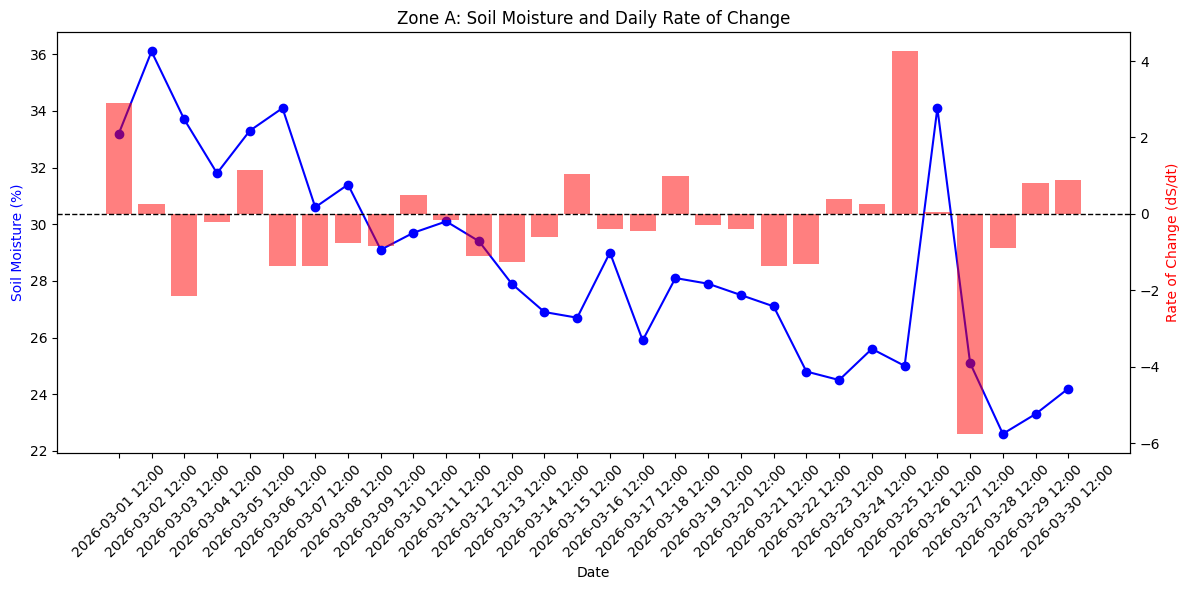

In [15]:
# Extract Zone A data
zone_a = soil_df[soil_df['zone_id'] == 'Zone_A'].copy()
moisture_array = zone_a['soil_moisture_pct'].values

# Calculate rate of change using Central Difference (h=1 day)
rate_of_change = central_difference(moisture_array, h=1.0)
zone_a['moisture_derivative'] = rate_of_change

# Plotting the Moisture and its Derivative
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(zone_a['timestamp'], zone_a['soil_moisture_pct'], color='blue', marker='o', label='Soil Moisture (%)')
ax1.set_ylabel('Soil Moisture (%)', color='blue')
ax1.set_xlabel('Date')
plt.xticks(rotation=45)

ax2 = ax1.twinx()
ax2.bar(zone_a['timestamp'], zone_a['moisture_derivative'], color='red', alpha=0.5, label='Rate of Change (%/day)')
ax2.set_ylabel('Rate of Change (dS/dt)', color='red')
ax2.axhline(0, color='black', linewidth=1, linestyle='--')

plt.title('Zone A: Soil Moisture and Daily Rate of Change')
fig.tight_layout()
plt.show()

## Convergence Analysis 
### 4. Empirical Convergence Performance
---
We tabulate the operational parameters of our from-scratch root finders to systematically isolate the most efficient implementation for continuous runtime deployment.

In [16]:
# Constructing a data frame to hold empirical tracking variables
results_data = []
for name, method in [("Bisection", lambda: bisection_method(et_target_func, 10, 50)),
                     ("Newton-Raphson", lambda: newton_raphson_method(et_target_func, et_deriv_func, 25)),
                     ("Secant", lambda: secant_method(et_target_func, 20, 30))]:
    root, iters, final_err, status = method()
    results_data.append({"Method": name, "Calculated Root (°C)": round(root, 4), 
                         "Iterations": iters, "Final Absolute Error": f"{final_err:.2e}", "Status": status})

pd.DataFrame(results_data)

,Method,Calculated Root (°C),Iterations,Final Absolute Error,Status
0,Bisection,42.2501,17,7.32e-06,Converged
1,Newton-Raphson,42.2500,1,8.88e-16,Converged
2,Secant,42.2500,1,8.88e-16,Converged


## Step-by-Step Numerical Integration Instructions
### 5. Applied Numerical Integration: 
#### Cumulative Water Deficit Scientific Context: 
---
To quantify prolonged moisture deficit stress, we determine the daily deviation of soil moisture beneath the optimized target threshold for Zone A ($Target = 33\%$). We integrate this metric across our 30-day monitoring timeline to generate a unified index of total water stress (expressed in %-days).Note for Implementation: Because our 30-day monitoring run yields exactly 30 chronological measurements, we possess 29 unique computation intervals. Since Simpson's rule strictly demands an even number of intervals, we slice our array to the first 29 sequential points (producing 28 intervals) to maintain theoretical mathematical precision.

In [17]:
# Isolate Zone A tracking parameters
zone_a_data = soil_df[soil_df['zone_id'] == 'Zone_A'].copy()
moisture_readings = zone_a_data['soil_moisture_pct'].values
target_threshold = 33.0

# Calculate raw moisture deficits (setting any surplus values above target to 0)
daily_deficits = np.maximum(0, target_threshold - moisture_readings)

# Integration using an even subset of 28 intervals (29 points) for comparison
subset_deficits = daily_deficits[:29]

val_trapezoid = trapezoidal_rule(subset_deficits, dx=1.0)
val_simpson = simpsons_rule(subset_deficits, dx=1.0)

print(f"--- Numerical Integration Benchmark (28 Intervals) ---")
print(f"Trapezoidal Rule Total Stress: {val_trapezoid:.4f} %-days")
print(f"Simpson's 1/3 Rule Total Stress: {val_simpson:.4f} %-days")
print(f"Absolute Discrepancy:          {abs(val_trapezoid - val_simpson):.6f} %-days")

--- Numerical Integration Benchmark (28 Intervals) ---
Trapezoidal Rule Total Stress: 124.1500 %-days
Simpson's 1/3 Rule Total Stress: 120.2333 %-days
Absolute Discrepancy:          3.916667 %-days


## Matrix Systems Allocation Solver
### 6. Applied Linear Systems: 
#### Multi-Zone Water Volume Allocation Scientific Context:
---
 Suppose JKUAT's micro-irrigation manifold routes water to Zone A ($x_1$), Zone B ($x_2$), and Zone C ($x_3$) concurrently. We construct a static structural model representing network delivery limitations, pipeline hydraulic friction balancing, and optimal crop demand ratios:Volumetric Flow Conservation: Total aggregate delivery target = $1000$ LitersFriction Loss Limit: Combined pipeline fluid resistance layout profile: $2x_1 + 1.5x_2 + 3x_3 = 2325$Absorption Flow Ratio: Balanced agricultural operational constraint: $-x_1 + 2x_2 = 200$This mapping yields the classical linear system $Ax = b$:$$\begin{bmatrix} 1 & 1 & 1 \\ 2 & 1.5 & 3 \\ -1 & 2 & 0 \end{bmatrix} \begin{bmatrix} x_1 \\ x_2 \\ x_3 \end{bmatrix} = \begin{bmatrix} 1000 \\ 2325 \\ 200 \end{bmatrix}$$

In [ ]:
# Construct systemic coefficient array and balancing vector
matrix_A = [[1.0, 1.0, 1.0],
            [2.0, 1.5, 3.0],
            [-1.0, 2.0, 0.0]]

vector_b = [1000.0, 2325.0, 200.0]

# Compute solution using custom engine
allocation_solutions = gaussian_elimination(matrix_A, vector_b)

# Verification using native numpy routines
numpy_verification = np.linalg.solve(matrix_A, vector_b)

print("--- Multi-Zone Allocation Vector Solutions ---")
print(f"Zone A (Tomato) Allocation : {allocation_solutions[0]:.2f} Liters")
print(f"Zone B (Kale) Allocation   : {allocation_solutions[1]:.2f} Liters")
print(f"Zone C (Maize) Allocation  : {allocation_solutions[2]:.2f} Liters")

--- Multi-Zone Allocation Vector Solutions ---
Zone A (Tomato) Allocation : 300.00 Liters
Zone B (Kale) Allocation   : 250.00 Liters
Zone C (Maize) Allocation  : 450.00 Liters

Numerical Matrix Solution Verified via NumPy: True
